# Export an ephemeris to CCSDS-OEM

This notebook walks through `Results.write_oem(...)`: take whatever ephemeris GMAT just wrote, hand it to the writer, and get a clean CCSDS-OEM file out.

The interesting case is the one that does real work — a *format conversion*. We point GMAT at a stock sample (`Ex_STKEphemOutput.script`) that emits an `EphemerisFile` in **STK TimePosVel** format, parse it through `result.ephemerides[...]`, and write the same trajectory back out as CCSDS-OEM. The `gmat-run` writer handles the frame-name translation (STK's `J2000` &rarr; CCSDS's `EME2000`), tags the file with our originator and object name, and emits `CCSDS_OEM_VERS = 1.0` so the output round-trips through GMAT's own OEM reader.

**Prerequisites.** A local GMAT install (R2026a is the primary development target) and `pip install gmat-run[ccsds-ndm,examples]` for the OEM writer and matplotlib.

## Locate the stock script

`gmat_run.locate_gmat()` returns a `GmatInstall` describing the resolved install. We use that to find a script that ships with GMAT instead of hard-coding a path.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt

from gmat_run import Mission, locate_gmat
from gmat_run.parsers.ephemeris import parse as parse_oem

install = locate_gmat()
script_path = install.root / "samples" / "Ex_STKEphemOutput.script"

print(f"GMAT version: {install.version}")
print(f"Script:       <install>/{script_path.relative_to(install.root)}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       <install>/samples/Ex_STKEphemOutput.script
Exists:       True


## Run the mission

`Ex_STKEphemOutput` declares one `EphemerisFile` resource named `EphemerisFile1` with `FileFormat = STK-TimePosVel` and `CoordinateSystem = EarthMJ2000Eq`. `mission.run()` executes the mission sequence headlessly and returns a `Results` object; the file path GMAT wrote is exposed at `result.ephemeris_paths["EphemerisFile1"]`.

In [2]:
mission = Mission.load(script_path)
result = mission.run()

ephem_path = result.ephemeris_paths["EphemerisFile1"]
print(f"Ephemeris resources:  {list(result.ephemerides)}")
print(f"On-disk filename:     {ephem_path.name}")
print(f"On-disk size (bytes): {ephem_path.stat().st_size}")

Ephemeris resources:  ['EphemerisFile1']
On-disk filename:     EphemerisFile1.e
On-disk size (bytes): 20682


## Inspect the parsed ephemeris

`Results.ephemerides` lazy-parses each file on first access and caches the DataFrame. The parser sniffs the file's magic to dispatch — STK-TimePosVel here, but the same call site also handles CCSDS-OEM and SPK without any extra ceremony.

The metadata you'll need for OEM emission is surfaced flat on `df.attrs` — `coordinate_system`, `central_body`, and the time scale (here under `time_scale`; multi-segment OEM files also populate `epoch_scales["Epoch"]`). For this STK file the parser also surfaces `scenario_epoch` and `distance_unit` — useful provenance, ignored by the OEM writer.

In [3]:
ephem = result.ephemerides["EphemerisFile1"]

print(f"Records:           {len(ephem)}")
print(f"Coordinate system: {ephem.attrs.get('coordinate_system')!r}")
print(f"Central body:      {ephem.attrs.get('central_body')!r}")
print(f"Time scale:        {ephem.attrs.get('time_scale')!r}")
print(f"Scenario epoch:    {ephem.attrs.get('scenario_epoch')!r}")
ephem.head()

Records:           123
Coordinate system: 'J2000'
Central body:      'Earth'
Time scale:        'UTC'
Scenario epoch:    '01 Jan 2000 11:59:28.000'


,Epoch,X,Y,Z,VX,VY,VZ
0,2000-01-01 11:59:28.000000000,7100.000000,0.000000,1300.000000,0.000000,7.350000,1.000000
1,2000-01-01 12:00:27.999999881,7086.464536,440.720032,1357.477178,-0.450703,7.336012,0.915359
2,2000-01-01 12:02:02.685242125,7010.405940,1132.160095,1437.587570,-1.153784,7.257613,0.775608
3,2000-01-01 12:03:42.622872081,6858.692139,1850.295726,1507.438986,-1.878902,7.101738,0.621252
4,2000-01-01 12:05:23.493273330,6633.262491,2555.614960,1562.009970,-2.586068,6.870866,0.459974


## Write a CCSDS-OEM file

`Results.write_oem(name, path, *, originator=..., object_name=...)` materialises the ephemeris through the lazy parser and emits a single-segment KVN OEM at `path`. The `originator` and `object_name` keyword arguments override the file header and the `OBJECT_NAME` meta field respectively — when `object_name` is omitted, the writer falls back to `df.attrs["object_name"]` and then to `"UNKNOWN"`.

Two things worth knowing about the output:

- The writer translates GMAT/STK frame aliases (`J2000`, `EarthMJ2000Eq`, `EarthICRF`) to their CCSDS canonical names (`EME2000`, `ICRF`). Anything outside that table raises a `ValueError` rather than emitting a non-conforming file.
- GMAT R2026a's CCSDS-OEM reader rejects `CCSDS_OEM_VERS = 3.0` outright and treats `2.0` as gated behind a "TESTING mode" flag. The writer therefore emits `1.0` regardless of what `ccsds-ndm` produced internally, so the file round-trips back through GMAT.

We write into a per-session temp directory so the file persists across the cells below without polluting the working tree.

In [4]:
workdir = Path(tempfile.mkdtemp(prefix="oem-export-"))
oem_path = workdir / "theSat.oem"

written = result.write_oem(
    "EphemerisFile1",
    oem_path,
    originator="astro-tools/gmat-run docs example",
    object_name="THESAT",
)

print(f"Written:    {written.name}")
print(f"Size:       {written.stat().st_size} bytes")
print()
print("--- OEM header ---")
header_lines = written.read_text(encoding="utf-8").splitlines()[:13]
print("\n".join(header_lines))

Written:    theSat.oem
Size:       17808 bytes

--- OEM header ---
CCSDS_OEM_VERS           = 1.0

CREATION_DATE            = 2026-04-28T03:05:24.309
ORIGINATOR               = astro-tools/gmat-run docs example

META_START
OBJECT_NAME              = THESAT
OBJECT_ID                = THESAT
CENTER_NAME              = Earth
REF_FRAME                = EME2000
TIME_SYSTEM              = UTC
START_TIME               = 2000-01-01T11:59:28.000
STOP_TIME                = 2000-01-01T15:19:28.000


## Re-parse the emitted OEM

`gmat_run.parsers.ephemeris.parse` is the same OEM parser the lazy `Results.ephemerides` mapping dispatches to under the hood; it operates on a path, so we can point it at the file we just wrote and confirm the round-trip is clean. The `coordinate_system` attr now reads `EME2000` (the canonical CCSDS name the writer translated `J2000` to) and `object_name` carries the override we passed in.

In [5]:
reparsed = parse_oem(written)

print(f"Records:           {len(reparsed)}")
print(f"Coordinate system: {reparsed.attrs.get('coordinate_system')!r}")
print(f"Object name:       {reparsed.attrs.get('object_name')!r}")
print(f"Time scale:        {reparsed.attrs.get('time_scale')!r}")
reparsed.head()

Records:           123
Coordinate system: 'EME2000'
Object name:       'THESAT'
Time scale:        'UTC'


,Epoch,X,Y,Z,VX,VY,VZ
0,2000-01-01 11:59:28.000,7100.000000,0.000000,1300.000000,0.000000,7.350000,1.000000
1,2000-01-01 12:00:27.999,7086.464536,440.720032,1357.477178,-0.450703,7.336012,0.915359
2,2000-01-01 12:02:02.685,7010.405940,1132.160095,1437.587570,-1.153784,7.257613,0.775608
3,2000-01-01 12:03:42.622,6858.692139,1850.295726,1507.438986,-1.878902,7.101738,0.621252
4,2000-01-01 12:05:23.493,6633.262491,2555.614960,1562.009970,-2.586068,6.870866,0.459974


## Visualise the trajectory in 3D

The OEM is in EME2000 — an Earth-centred inertial frame — so plotting `(X, Y, Z)` straight out of the DataFrame gives a meaningful inertial trajectory. We add a unit sphere scaled to Earth's mean radius for a sense of scale, and equalise the axis limits so the orbit's geometry is not visually distorted.

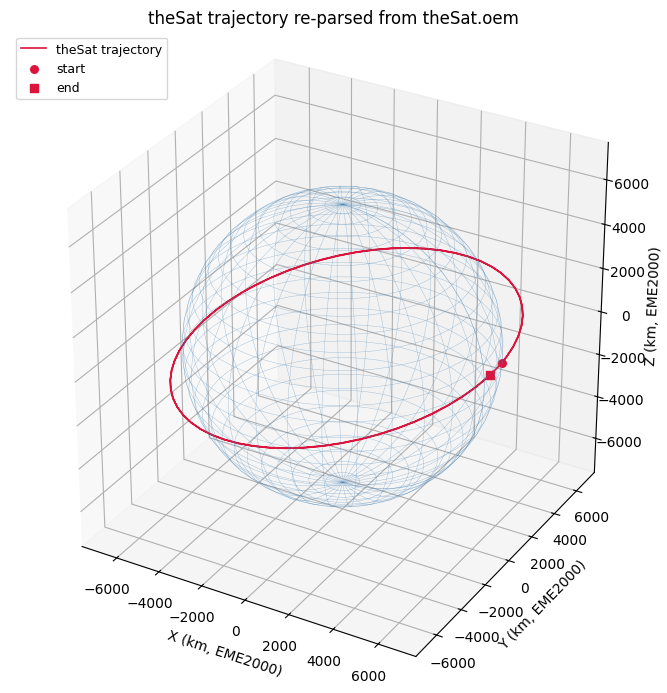

In [6]:
import numpy as np

EARTH_RADIUS_KM = 6378.137  # WGS-84 equatorial radius

x = reparsed["X"].to_numpy()
y = reparsed["Y"].to_numpy()
z = reparsed["Z"].to_numpy()

theta, phi = np.meshgrid(np.linspace(0, 2 * np.pi, 60), np.linspace(0, np.pi, 30))
ex = EARTH_RADIUS_KM * np.cos(theta) * np.sin(phi)
ey = EARTH_RADIUS_KM * np.sin(theta) * np.sin(phi)
ez = EARTH_RADIUS_KM * np.cos(phi)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_wireframe(ex, ey, ez, color="steelblue", linewidth=0.3, alpha=0.5)
ax.plot(x, y, z, color="crimson", linewidth=1.2, label="theSat trajectory")
ax.scatter(x[0], y[0], z[0], color="crimson", s=30, marker="o", label="start")
ax.scatter(x[-1], y[-1], z[-1], color="crimson", s=30, marker="s", label="end")

limit = max(np.abs([x, y, z]).max(), EARTH_RADIUS_KM) * 1.05
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)
ax.set_box_aspect((1, 1, 1))
ax.set_xlabel("X (km, EME2000)")
ax.set_ylabel("Y (km, EME2000)")
ax.set_zlabel("Z (km, EME2000)")
ax.set_title(f"theSat trajectory re-parsed from {written.name}")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## Where to next

- **Batch export.** `result.write_oem_all(dirpath)` writes every ephemeris in `result.ephemerides` to `<dirpath>/<name>.oem` in one call — convenient for missions that declare several `EphemerisFile` resources.
- **Other source formats.** The lazy `Results.ephemerides` mapping also handles CCSDS-OEM (GMAT's default text writer) and SPK (binary, via the `[spiceypy]` extra) inputs, so the same `write_oem` call works regardless of which `FileFormat` GMAT was configured to write.
- **Persist the artefacts.** `result.persist("./run_outputs")` after `run()` copies the GMAT-emitted `EphemerisFile` (alongside any `ReportFile` / `ContactLocator` outputs) into a permanent location before the temp workspace is cleaned up — useful when you want both the original STK ephemeris and the converted OEM on disk.